# [Project Title]

**Course:**  Foundations of Data Science

**Group Members:** [Member Name 1], [Member Name 2], [Member Name 3]

## 1. Introduction


### 1.1. The Question / Estimand

*(Provide a clear statement of the question you are investigating.)*

### 1.2. Data Description

*(Describe the dataset you are using. )*
* *Where did the data come from? (Provide a link or upload it).*
* *What do the rows and columns represent?*
* *Why is this dataset appropriate for your causal question?*

## 2. Causal Model

*(Describe your causal model. This section must include a **connected** Directed Acyclic Graph (DAG). Insert an image of your DAG here or create it with code.)*

### 2.1. Variables

*(Clearly label and describe your three variables (Treatment, Outcome, Confound). Do not use T,Y,Z. Use symbols that reflect the names of the variables from your dataset.)*

* **T (Treatment):** [Variable Name] - [Description]
* **Y (Outcome):** [Variable Name] - [Description]
* **Z (Confound):** [Variable Name] - [Description]

### 2.2. Assumed Causal Relationships

*(Clearly describe the assumed causal relationships between the variables as represented in your DAG. )*

### **3. Statistical Model**

Because the outcome is binary, we use a Bayesian Bernoulli generalized linear model with a logit link. Let $Y_i$ represent whether voter $i$ voted for the Democratic House candidate, where $Y_i = 1$ indicates a Democratic vote and $Y_i = 0$ otherwise. Let $E_i$ represent the voter’s national economic perception category, and let $P_i$ represent their party identification.

$$
Y_i \sim \text{Bernoulli}(p_i)
$$

$$
\text{logit}(p_i) = \alpha + \beta_E[E_i] + \beta_P[P_i]
$$

$$
\alpha \sim \text{Normal}(0, 1)
$$

$$
\beta_E[j] \sim \text{Normal}(0, 0.5), \quad j = 1, \dots, 5
$$

$$
\beta_P[k] \sim \text{Normal}(0, 1), \quad k \in \{\text{Democrat}, \text{Independent}, \text{Republican}\}
$$

Here, $\beta_E[E_i]$ is a categorical effect for economic perception, meaning each economic perception level gets its own parameter. We choose this specification because exploratory analysis and model comparison showed that the effect of economic perception is not well represented as a smooth linear or polynomial trend. The categorical model performed better under WAIC and is more appropriate because it does not assume equal spacing between ordinal categories.

---

### **3.1. Justification of Priors**

The priors are weakly informative and were chosen using prior predictive simulation, following the same class workflow used in the binomial and Poisson GLM assignments. The intercept prior $\alpha \sim \text{Normal}(0, 1)$ places most prior probability on moderate baseline voting probabilities after transformation through the logistic function, rather than forcing probabilities close to 0 or 1. 

The economic perception effects use $\text{Normal}(0, 0.5)$, which allows meaningful shifts in log-odds across perception categories while preventing unrealistically extreme prior vote probabilities. The party identification effects use $\text{Normal}(0, 1)$, since party identity is expected to strongly predict vote choice, but the prior still allows uncertainty in the size of that effect. Prior predictive simulations confirmed that these priors generated plausible probabilities across economic perception levels and party groups, rather than producing degenerate predictions near 0 or 1. This follows the prior predictive checking approach used in the course assignments on GLMs.

### **3.2. Justification of Outcome Distribution**

A Bernoulli outcome distribution is appropriate because the response variable is binary: each voter either voted for the Democratic House candidate or did not. Since $Y_i$ can only take values 0 and 1, a Normal likelihood would be inappropriate. The Bernoulli likelihood directly models the probability of a Democratic vote, and the logit link maps the linear predictor to a valid probability between 0 and 1. This matches the generalized linear model structure used in class for binary/binomial outcomes such as admissions and grant decisions.

### **3.3. Handling the Confound**

Party identification is included in the model as $\beta_P[P_i]$ because it is a confounder: it plausibly affects both national economic perception and vote choice. Partisanship can shape how voters interpret national economic conditions, and it also strongly influences whether they vote for the Democratic or Republican candidate. By conditioning on party identification, the model compares voters with different economic perceptions while holding party identity constant. This blocks the backdoor path from economic perception to vote choice through party identification, following the DAG/backdoor adjustment logic used in class.

## 4. Model Validation on Simulated Data

*(Before analyzing the real data, you must validate your statistical model on simulated data where you pre-define the parameter values, construct a posterior approximation of your model using the simulated data, and evaluate how well your model estimates the pre-defined parameter values.)*

*(**Hint:** Use `arviz.plot_posterior()` with the `ref_val` parameter set to your fixed simulation parameter values to check how well your model estimates them. )*

/opt/homebrew/Caskroom/miniconda/base/envs/fds-project/lib/python3.10/site-packages/arviz/rcparams.py:345: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_econ, beta_party]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 21 seconds.


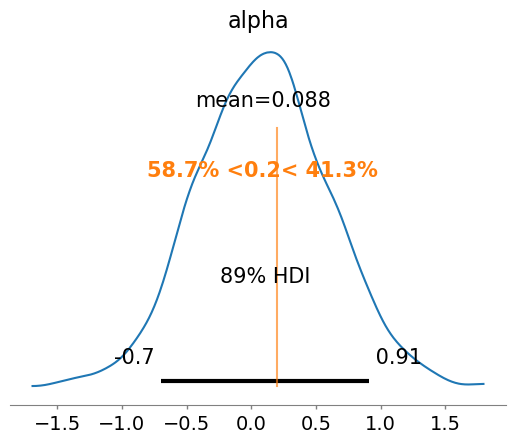

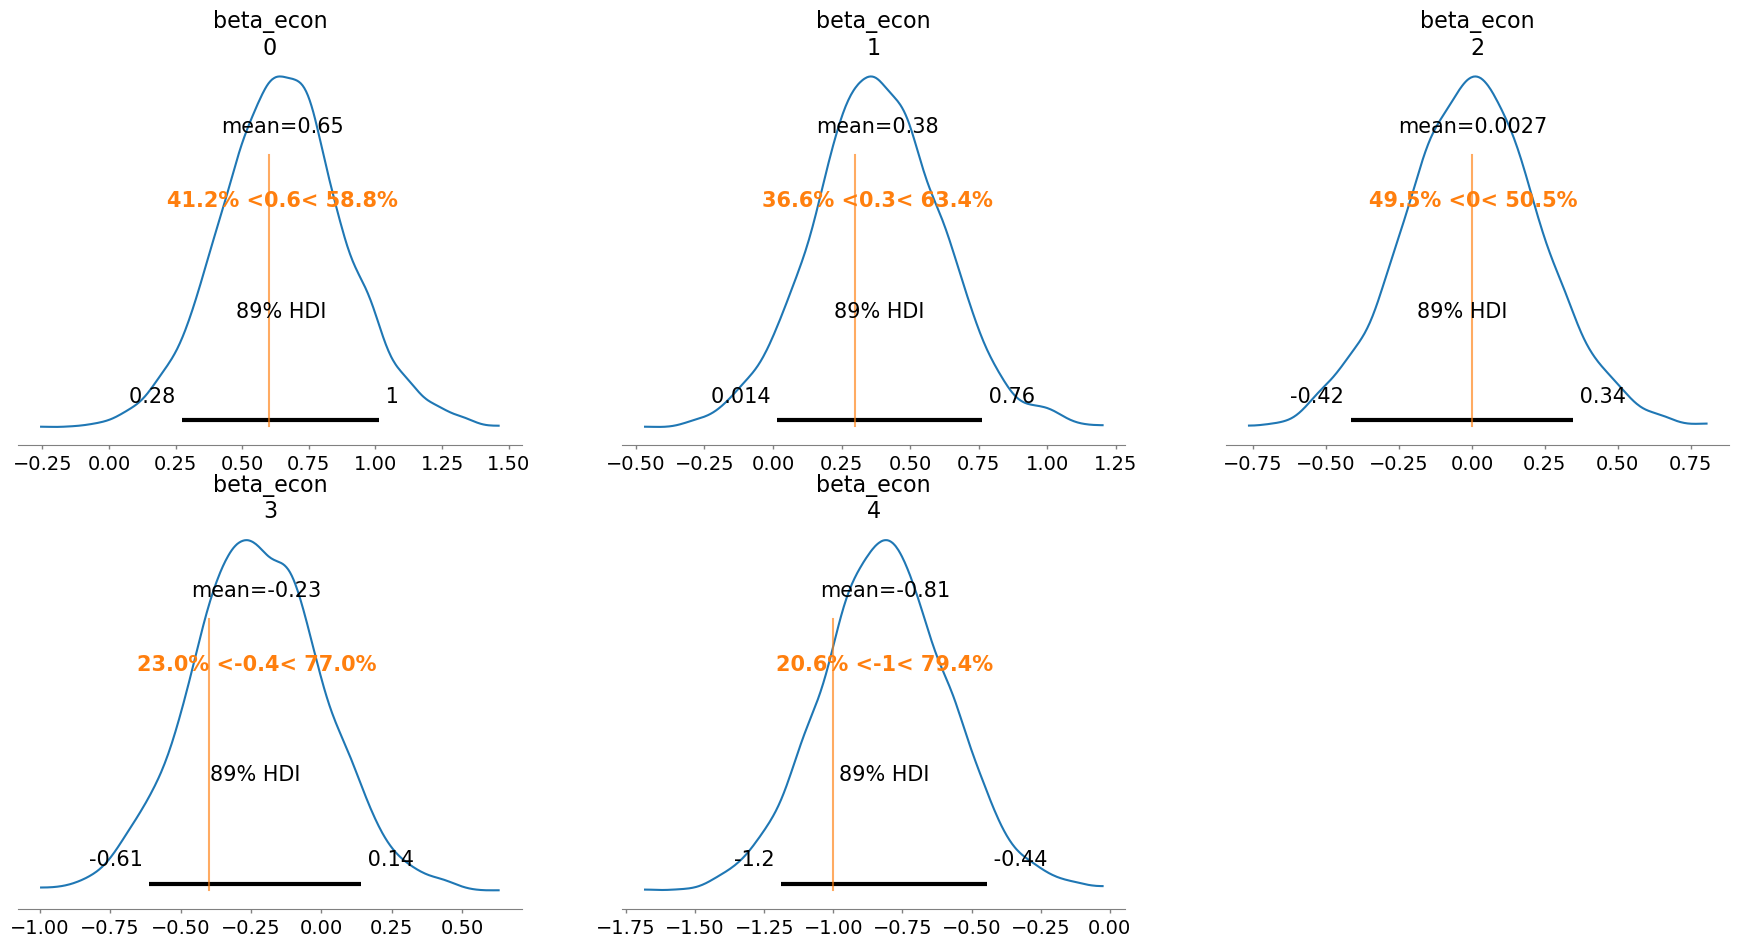

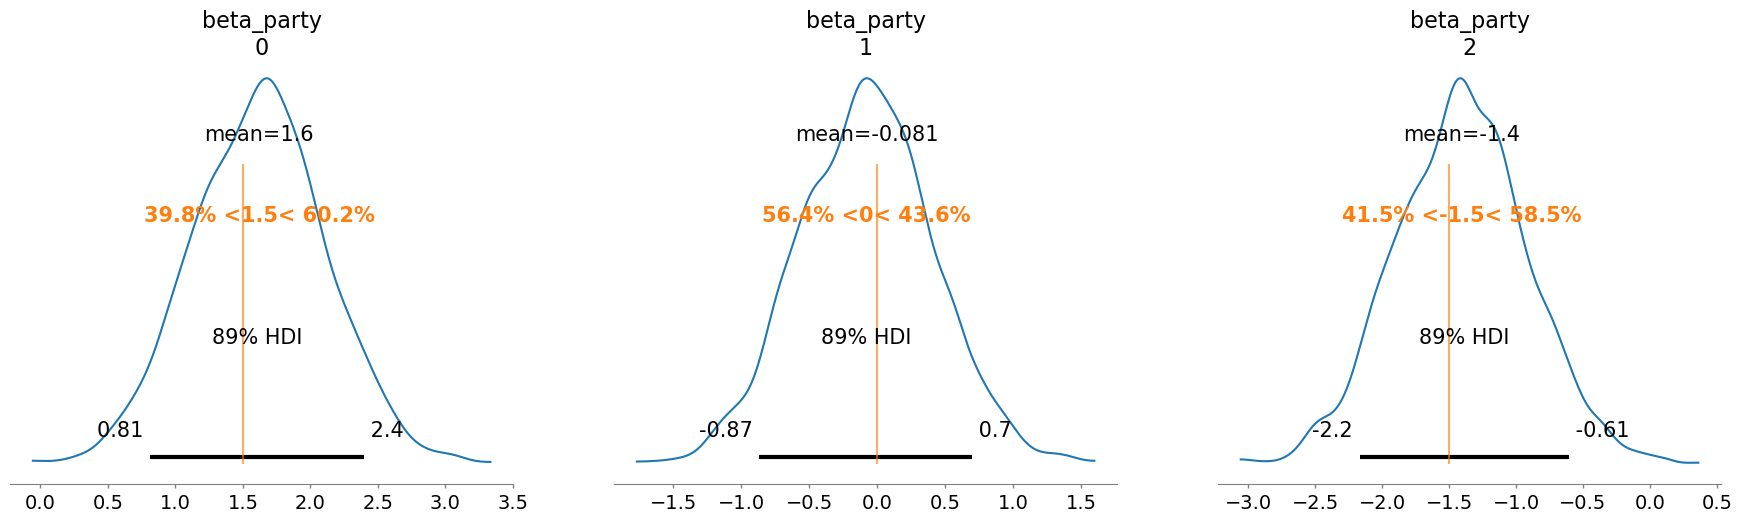

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.088,0.515,-0.698,0.908,0.016,0.011,1045.0,1235.0,1.00
beta_econ[0],0.652,0.234,0.276,1.015,0.009,0.006,682.0,1082.0,1.00
beta_econ[1],0.382,0.236,0.014,0.762,0.008,0.006,835.0,1088.0,1.00
beta_econ[2],0.003,0.235,-0.415,0.345,0.009,0.006,704.0,1039.0,1.01
beta_econ[3],-0.231,0.235,-0.611,0.139,0.009,0.006,713.0,1093.0,1.00
beta_econ[4],-0.814,0.236,-1.190,-0.444,0.009,0.006,762.0,1080.0,1.00
beta_party[0],1.620,0.497,0.814,2.395,0.015,0.012,1156.0,1454.0,1.00
beta_party[1],-0.081,0.496,-0.870,0.699,0.015,0.011,1133.0,1416.0,1.00
beta_party[2],-1.406,0.496,-2.170,-0.606,0.015,0.011,1129.0,1420.0,1.00


In [2]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
from scipy.special import expit
import matplotlib.pyplot as plt

az.rcParams["stats.hdi_prob"] = 0.89

np.random.seed(42)

# ----------------------------
# 1. Fixed true parameter values
# ----------------------------

N_sim = 5000

alpha_sim = 0.2

# Economic perception levels: 1, 2, 3, 4, 5
beta_econ_sim = np.array([0.6, 0.3, 0.0, -0.4, -1.0])

# Party order: Democrat, Independent, Republican
beta_party_sim = np.array([1.5, 0.0, -1.5])

# ----------------------------
# 2. Simulate data
# ----------------------------

econ_sim = np.random.choice([1, 2, 3, 4, 5], size=N_sim)
party_sim = np.random.choice([0, 1, 2], size=N_sim)

econ_idx_sim = econ_sim - 1
party_idx_sim = party_sim

logit_p_sim = (
    alpha_sim
    + beta_econ_sim[econ_idx_sim]
    + beta_party_sim[party_idx_sim]
)

p_sim = expit(logit_p_sim)

y_sim = np.random.binomial(n=1, p=p_sim, size=N_sim)

sim_df = pd.DataFrame({
    "econ_perception": econ_sim,
    "econ_idx": econ_idx_sim,
    "party_idx": party_idx_sim,
    "voted_dem_house": y_sim
})

# ----------------------------
# 3. Fit PyMC model to simulated data
# ----------------------------

with pm.Model() as sim_cat_model:

    alpha = pm.Normal("alpha", 0, 1)

    beta_econ = pm.Normal("beta_econ", 0, 0.5, shape=5)

    beta_party = pm.Normal("beta_party", 0, 1, shape=3)

    mu = (
        alpha
        + beta_econ[sim_df["econ_idx"].values.astype(int)]
        + beta_party[sim_df["party_idx"].values.astype(int)]
    )

    p = pm.Deterministic("p", pm.math.sigmoid(mu))

    y_obs = pm.Bernoulli(
        "y_obs",
        p=p,
        observed=sim_df["voted_dem_house"].values.astype(int)
    )

    sim_cat_trace = pm.sample(
        1000,
        tune=1000,
        target_accept=0.9,
        idata_kwargs={"log_likelihood": True}
    )

# ----------------------------
# 4. Check parameter recovery
# ----------------------------

az.plot_posterior(
    sim_cat_trace,
    var_names=["alpha"],
    ref_val=alpha_sim,
    hdi_prob=0.89
)
plt.show()

az.plot_posterior(
    sim_cat_trace,
    var_names=["beta_econ"],
    ref_val=list(beta_econ_sim),
    hdi_prob=0.89
)
plt.show()

az.plot_posterior(
    sim_cat_trace,
    var_names=["beta_party"],
    ref_val=list(beta_party_sim),
    hdi_prob=0.89
)
plt.show()

az.summary(
    sim_cat_trace,
    var_names=["alpha", "beta_econ", "beta_party"],
    hdi_prob=0.89
)


### **4. Model Validation on Simulated Data — Discussion**

The simulation results demonstrate that the model is able to successfully recover the true parameter values used to generate the data. For the intercept parameter, the posterior mean is close to the true value $\alpha = 0.2$, and the 89% highest density interval (HDI) contains the true value, indicating accurate recovery despite some sampling variability.

The economic perception parameters are also well recovered. The posterior estimates closely match the true values $\beta_E = [0.6, 0.3, 0.0, -0.4, -1.0]$, with the correct direction and relative magnitudes across all categories. In particular, the model accurately captures the strong negative effect associated with the worst economic perception level. For all economic perception parameters, the true values lie within the corresponding 89% HDIs, demonstrating that the model is capable of recovering both positive and negative category-specific effects.

Similarly, the party identification parameters are recovered effectively. The posterior means for $\beta_P = [1.5, 0.0, -1.5]$ are close to the true values, and the HDIs include the true parameters for all party groups. This indicates that the model successfully captures strong partisan differences in voting behavior.

In addition, convergence diagnostics show that $\hat{R} \approx 1$ for all parameters and effective sample sizes are sufficiently large, indicating stable and reliable posterior estimation.

Overall, these results confirm that the model is correctly specified and that the Bayesian estimation procedure is able to recover known parameter values when the data-generating process matches the assumed model. This provides confidence that the model can be appropriately applied to the real dataset for inference.

## 5. Data Preparation (Real Data)

*(Load the real dataset. Perform any necessary cleaning, scaling, or transformations. )*

In [3]:
# Step 1: Load data
data = pd.read_csv("../data/raw/raw.csv", low_memory=False)

# Step 2: Keep all needed columns
cols = ["CC22_302", "CC22_412", "pid3", 
        "HouseCand1Party", "HouseCand2Party", "HouseCand3Party",
        "HouseCand4Party", "HouseCand5Party", "HouseCand6Party",
        "HouseCand7Party", "HouseCand8Party"]

df = data[cols].dropna(subset=["CC22_302", "CC22_412", "pid3"])


# Step 3: Filter valid econ_perception values (1-5 only, drop 6 = Not sure)
df = df[df["CC22_302"].isin([1, 2, 3, 4, 5])]

# Step 4: Filter valid CC22_412 values (1-8 only, drop 10,11,12,13)
df = df[df["CC22_412"].isin([1, 2, 3, 4, 5, 6, 7, 8])]

# Step 5: Map vote to Democrat (1) or not (0)
def map_voted_dem(row):
    vote = row["CC22_412"]
    party_col = f"HouseCand{int(vote)}Party"
    party = row[party_col]
    if party == "Democratic":
        return 1
    elif pd.notna(party):
        return 0
    return np.nan

df["voted_dem_house"] = df.apply(map_voted_dem, axis=1)

# Step 6: Drop rows where mapping failed
df = df.dropna(subset=["voted_dem_house"])

# Step 7: Map party_id integers to labels
df["party_id"] = df["pid3"].map({
    1: "Democrat",
    2: "Republican",
    3: "Independent",
    4: "Other",
    5: "Not sure"
})

# Step 8: Drop ambiguous party categories
df = df[df["party_id"].isin(["Democrat", "Republican", "Independent"])]

# Step 9: Rename and keep only needed columns
df = df.rename(columns={"CC22_302": "econ_perception"})
df = df[["econ_perception", "voted_dem_house", "party_id"]]

# Step 10: Sanity checks
print("Shape:", df.shape)
print("\nVote distribution:")
print(df["voted_dem_house"].value_counts())
print("\nParty distribution:")
print(df["party_id"].value_counts())
print("\nEcon perception distribution (should be 1-5 only):")
print(df["econ_perception"].value_counts().sort_index())
print("\nSample:")
df.head(20)

Shape: (35628, 3)

Vote distribution:
voted_dem_house
1.0    20025
0.0    15603
Name: count, dtype: int64

Party distribution:
party_id
Democrat       15445
Republican     10645
Independent     9538
Name: count, dtype: int64

Econ perception distribution (should be 1-5 only):
econ_perception
1.0     1273
2.0     4556
3.0     4266
4.0     9852
5.0    15681
Name: count, dtype: int64

Sample:


,econ_perception,voted_dem_house,party_id
0,2.0,1.0,Democrat
1,5.0,0.0,Independent
2,4.0,1.0,Democrat
5,5.0,0.0,Independent
7,2.0,1.0,Democrat
8,4.0,1.0,Democrat
9,2.0,1.0,Democrat
12,4.0,1.0,Independent
13,5.0,0.0,Independent
14,4.0,1.0,Democrat


## 6. Posterior Model (Analysis on Real Data)

*(This section contains the code for your computational model and the analysis of its output.)*

### 6.1. Computational Model Definition and Sampling

*(Provide the code for your PyMC model.  Ensure the code is well-organized and understandable. )*

In [4]:
# ----------------------------
# 6. Posterior Model: Real Data
# 6.1 Computational Model Definition and Sampling
# ----------------------------

import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

# Use 89% HDI, consistent with class assignments
az.rcParams["stats.hdi_prob"] = 0.89

# ----------------------------
# Prepare data for model
# ----------------------------

# Encode party identification
party_map = {
    "Democrat": 0,
    "Independent": 1,
    "Republican": 2
}

df["party_idx"] = df["party_id"].map(party_map)

# Economic perception levels 1–5 are converted to indices 0–4
econ_idx = df["econ_perception"].values.astype(int) - 1

# Party indices 0–2
party_idx = df["party_idx"].values.astype(int)

# Binary outcome: 1 = voted Democratic House candidate, 0 = otherwise
y = df["voted_dem_house"].values.astype(int)

# ----------------------------
# Categorical Bernoulli-logit model
# ----------------------------

with pm.Model() as cat_model:

    # Priors
    alpha = pm.Normal("alpha", 0, 1)

    # One effect for each economic perception level
    beta_econ = pm.Normal("beta_econ", 0, 0.5, shape=5)

    # One effect for each party identification group
    beta_party = pm.Normal("beta_party", 0, 1, shape=3)

    # Linear predictor on log-odds scale
    mu = (
        alpha
        + beta_econ[econ_idx]
        + beta_party[party_idx]
    )

    # Convert log-odds to probability
    p = pm.Deterministic("p", pm.math.sigmoid(mu))

    # Bernoulli likelihood
    y_obs = pm.Bernoulli("y_obs", p=p, observed=y)

    # Posterior sampling
    cat_trace = pm.sample(
        1000,
        tune=1000,
        target_accept=0.9,
        idata_kwargs={"log_likelihood": True}
    )


/opt/homebrew/Caskroom/miniconda/base/envs/fds-project/lib/python3.10/site-packages/arviz/rcparams.py:345: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_econ, beta_party]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 222 seconds.


### 6.2. Model Diagnostics

*(Use built-in diagnostics to assess the quality of the posterior samples (e.g., trace plots, r-hat, effective sample size). )*

Posterior Summary:


/opt/homebrew/Caskroom/miniconda/base/envs/fds-project/lib/python3.10/site-packages/arviz/rcparams.py:345: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.631,0.526,-0.254,1.461,0.017,0.012,969.0,973.0,1.00
beta_econ[0],0.520,0.236,0.121,0.878,0.007,0.005,1212.0,1481.0,1.00
beta_econ[1],0.881,0.222,0.524,1.230,0.007,0.005,1100.0,1408.0,1.00
beta_econ[2],0.686,0.221,0.331,1.031,0.007,0.005,1072.0,1412.0,1.00
beta_econ[3],0.003,0.216,-0.342,0.336,0.007,0.005,1064.0,1438.0,1.00
beta_econ[4],-1.915,0.216,-2.261,-1.588,0.007,0.005,1039.0,1395.0,1.00
beta_party[0],2.803,0.509,2.000,3.626,0.017,0.012,946.0,936.0,1.01
beta_party[1],0.164,0.508,-0.627,0.990,0.016,0.012,961.0,920.0,1.01
beta_party[2],-2.490,0.508,-3.277,-1.660,0.017,0.012,951.0,937.0,1.01


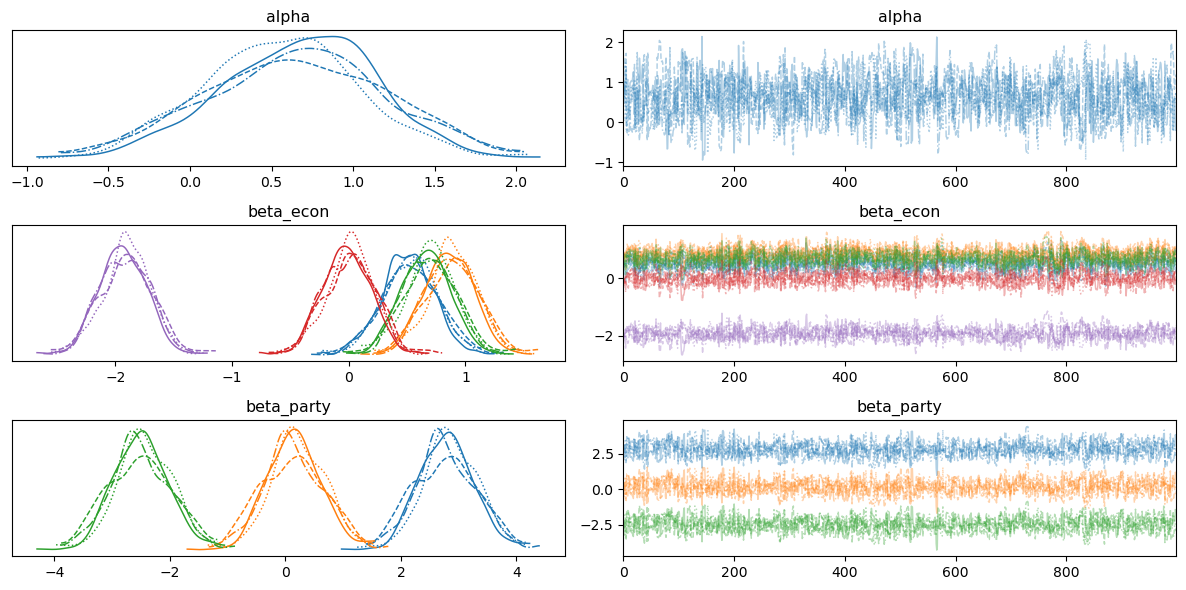


R-hat values (should be ~1.00):


<xarray.Dataset> Size: 136B
Dimensions:           (beta_econ_dim_0: 5, beta_party_dim_0: 3)
Coordinates:
  * beta_econ_dim_0   (beta_econ_dim_0) int64 40B 0 1 2 3 4
  * beta_party_dim_0  (beta_party_dim_0) int64 24B 0 1 2
Data variables:
    alpha             float64 8B 1.003
    beta_econ         (beta_econ_dim_0) float64 40B 1.002 1.003 ... 1.003 1.003
    beta_party        (beta_party_dim_0) float64 24B 1.006 1.006 1.005


Effective Sample Size (ESS):


<xarray.Dataset> Size: 136B
Dimensions:           (beta_econ_dim_0: 5, beta_party_dim_0: 3)
Coordinates:
  * beta_econ_dim_0   (beta_econ_dim_0) int64 40B 0 1 2 3 4
  * beta_party_dim_0  (beta_party_dim_0) int64 24B 0 1 2
Data variables:
    alpha             float64 8B 969.5
    beta_econ         (beta_econ_dim_0) float64 40B 1.212e+03 ... 1.039e+03
    beta_party        (beta_party_dim_0) float64 24B 946.3 960.8 950.6

In [5]:
# ----------------------------
# 6.2 Model Diagnostics
# ----------------------------

import arviz as az
import matplotlib.pyplot as plt

# Use 89% HDI (as per class)
az.rcParams["stats.hdi_prob"] = 0.89

# ----------------------------
# 1. Posterior Summary
# ----------------------------

diagnostics_summary = az.summary(
    cat_trace,
    var_names=["alpha", "beta_econ", "beta_party"],
    hdi_prob=0.89
)

print("Posterior Summary:")
display(diagnostics_summary)

# ----------------------------
# 2. Trace Plots
# ----------------------------

az.plot_trace(
    cat_trace,
    var_names=["alpha", "beta_econ", "beta_party"]
)

plt.tight_layout()
plt.show()

# ----------------------------
# 3. R-hat values
# ----------------------------

rhat_values = az.rhat(
    cat_trace,
    var_names=["alpha", "beta_econ", "beta_party"]
)

print("\nR-hat values (should be ~1.00):")
display(rhat_values)

# ----------------------------
# 4. Effective Sample Size (ESS)
# ----------------------------

ess_values = az.ess(
    cat_trace,
    var_names=["alpha", "beta_econ", "beta_party"]
)

print("\nEffective Sample Size (ESS):")
display(ess_values)

### **6.2. Model Diagnostics — Discussion**

The model diagnostics indicate that the posterior sampling has converged and the samples are of good quality. The trace plots show that all chains mix well and overlap substantially, with no visible trends or drifts over iterations. This suggests that the Markov chains have reached a stable stationary distribution and are adequately exploring the posterior.

The $\hat{R}$ values for all parameters are approximately **1.00**, which indicates convergence across chains. There is no evidence of non-convergence or chain disagreement. Additionally, the effective sample sizes (ESS) are sufficiently large for all parameters, indicating that the posterior estimates are based on a large number of effectively independent samples.

The posterior distributions are smooth and unimodal, further suggesting stable inference. There are no signs of pathological behavior such as multimodality or poor mixing. 

Overall, these diagnostics confirm that the model has converged successfully and that the posterior samples are reliable for inference.

## 7. Posterior Predictive Checks

*(Visually compare your model's posterior predictions to the observed data. )*

*(The plot(s) in this section should include: )*
* *The observed data*
* *The posterior mean*
* *The uncertainty of the posterior mean (e.g., 89% HDI)*
* *The uncertainty of posterior predictions (e.g., 89% HDI)*

/opt/homebrew/Caskroom/miniconda/base/envs/fds-project/lib/python3.10/site-packages/arviz/rcparams.py:345: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(
Sampling: [y_obs]


Output()

,party_id,econ_perception,observed,posterior_mean,posterior_mean_hdi_low,posterior_mean_hdi_high,posterior_pred_hdi_low,posterior_pred_hdi_high
0,Democrat,1,0.971983,0.981052,0.977467,0.984534,0.973060,0.988147
1,Democrat,2,0.971110,0.986762,0.985224,0.988456,0.982838,0.989703
2,Democrat,3,0.968750,0.983963,0.982103,0.985817,0.979514,0.987847
3,Democrat,4,0.960446,0.968792,0.966531,0.971236,0.964105,0.972992
4,Democrat,5,0.885928,0.820273,0.809716,0.829822,0.805162,0.837219
5,Independent,1,0.833333,0.787678,0.757546,0.819973,0.734234,0.842342
6,Independent,2,0.896045,0.842039,0.826776,0.856759,0.814689,0.863277
7,Independent,3,0.861692,0.814410,0.799230,0.829829,0.789809,0.838035
8,Independent,4,0.713398,0.689363,0.677409,0.702342,0.670291,0.707573
9,Independent,5,0.209796,0.245997,0.237179,0.255286,0.231869,0.258777


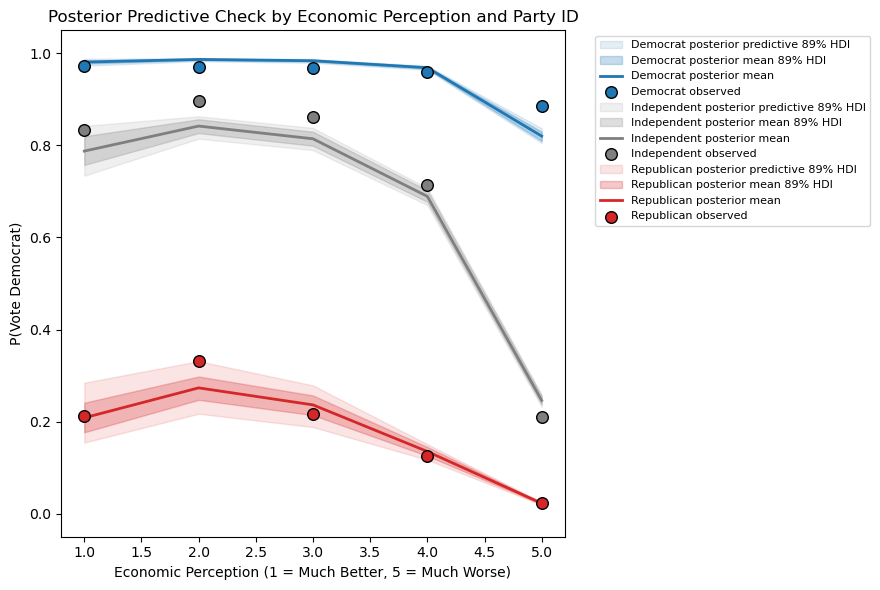

In [6]:
# ----------------------------
# 7. Posterior Predictive Checks
# ----------------------------

import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

az.rcParams["stats.hdi_prob"] = 0.89

# ----------------------------
# 1. Generate posterior predictive samples
# ----------------------------

with cat_model:
    cat_ppc = pm.sample_posterior_predictive(
        cat_trace,
        var_names=["y_obs"],
        random_seed=42
    )

# ----------------------------
# 2. Extract posterior probabilities and posterior predictive samples
# ----------------------------

# Posterior mean probabilities p_i
posterior_p = cat_trace.posterior["p"].values
posterior_p = posterior_p.reshape(-1, posterior_p.shape[-1])  # shape: draws x observations

# Posterior predictive simulated outcomes y_rep
y_rep = cat_ppc.posterior_predictive["y_obs"].values
y_rep = y_rep.reshape(-1, y_rep.shape[-1])  # shape: draws x observations

# ----------------------------
# 3. Prepare observed data
# ----------------------------

df_ppc = df.copy().reset_index(drop=True)

party_order = ["Democrat", "Independent", "Republican"]
party_colors = {
    "Democrat": "#1f77b4",
    "Independent": "#7f7f7f",
    "Republican": "#d62728"
}

rows = []

for party in party_order:
    for econ_level in [1, 2, 3, 4, 5]:

        mask = (
            (df_ppc["party_id"] == party) &
            (df_ppc["econ_perception"] == econ_level)
        ).values

        observed_mean = df_ppc.loc[mask, "voted_dem_house"].mean()

        # Posterior mean uncertainty:
        # average posterior probability inside this group for each posterior draw
        group_p_draws = posterior_p[:, mask].mean(axis=1)

        # Posterior predictive uncertainty:
        # average simulated outcomes inside this group for each posterior predictive draw
        group_yrep_draws = y_rep[:, mask].mean(axis=1)

        p_hdi = az.hdi(group_p_draws, hdi_prob=0.89)
        yrep_hdi = az.hdi(group_yrep_draws, hdi_prob=0.89)

        rows.append({
            "party_id": party,
            "econ_perception": econ_level,
            "observed": observed_mean,
            "posterior_mean": group_p_draws.mean(),
            "posterior_mean_hdi_low": p_hdi[0],
            "posterior_mean_hdi_high": p_hdi[1],
            "posterior_pred_hdi_low": yrep_hdi[0],
            "posterior_pred_hdi_high": yrep_hdi[1],
        })

ppc_summary = pd.DataFrame(rows)

display(ppc_summary)

# ----------------------------
# 4. Plot posterior predictive checks
# ----------------------------

fig, ax = plt.subplots(figsize=(9, 6))

for party in party_order:
    temp = ppc_summary[ppc_summary["party_id"] == party]

    x = temp["econ_perception"].values
    color = party_colors[party]

    # Posterior prediction uncertainty: wider interval
    ax.fill_between(
        x,
        temp["posterior_pred_hdi_low"],
        temp["posterior_pred_hdi_high"],
        color=color,
        alpha=0.12,
        label=f"{party} posterior predictive 89% HDI"
    )

    # Posterior mean uncertainty: narrower interval
    ax.fill_between(
        x,
        temp["posterior_mean_hdi_low"],
        temp["posterior_mean_hdi_high"],
        color=color,
        alpha=0.25,
        label=f"{party} posterior mean 89% HDI"
    )

    # Posterior mean line
    ax.plot(
        x,
        temp["posterior_mean"],
        color=color,
        linewidth=2,
        label=f"{party} posterior mean"
    )

    # Observed data points
    ax.scatter(
        x,
        temp["observed"],
        color=color,
        edgecolor="black",
        s=70,
        zorder=5,
        label=f"{party} observed"
    )

ax.set_xlabel("Economic Perception (1 = Much Better, 5 = Much Worse)")
ax.set_ylabel("P(Vote Democrat)")
ax.set_title("Posterior Predictive Check by Economic Perception and Party ID")
ax.set_ylim(-0.05, 1.05)

# Clean duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


### **7. Posterior Predictive Checks — Discussion**

The posterior predictive checks indicate that the model provides a good overall fit to the observed data. Across all party identification groups, the posterior mean closely follows the observed probabilities, and the observed data points generally lie within the 89% posterior predictive intervals. This suggests that the model is able to capture the main structure in the relationship between economic perception and voting behavior.

For Democratic voters, the model fits extremely well, with predicted probabilities remaining consistently high across all levels of economic perception and closely matching the observed values. For Republican voters, the model also captures the pattern accurately, including the sharp decline in the probability of voting for the Democratic candidate as economic perception worsens.

For Independent voters, the model captures the overall downward trend, but there is a notable discrepancy at the most negative economic perception level ($E = 5$). The observed probability drops sharply, while the posterior mean slightly underestimates the magnitude of this decline, although the observed value still lies within the predictive interval. This suggests that while the model captures the general trend, it smooths extreme behavior to some extent.

Overall, the posterior predictive intervals are reasonably tight and consistently cover the observed data, indicating that the model is neither underfitting nor overfitting. The slight discrepancies at extreme values reflect the model’s tendency to regularize estimates due to the priors and limited data in those regions.

In conclusion, the posterior predictive checks provide strong evidence that the model fits the observed data well and is appropriate for inference, while highlighting minor limitations in capturing extreme behavior.

## 8. Discussion and Conclusion

### 8.1. Answering the Question

*(Discuss what was learned from the model. )*
* *What is the answer to the question you posed in the introduction?*
* *What is your estimate for the causal effect? Provide a plot showing the estimate of the distribution of the causal effect.*
* *Ensure your conclusions are supported by the evidence from your model results.*

### 8.2. Addressing the Confound

*(Explicitly address the confounding variable in your discussion. )*
* *What was the effect of the confound?*

## 9. Future Work

*(Use your current model results to guide future plans for expanding the analysis. )*

* *What are the limitations of your model?*
* *What other variables would you want to include to expand your inquiry?*
* *What other questions might you explore given what you have learned from your analysis?*

## 10. Group Member Contributions

*(List each section of the proposal and final write-up and state who worked on it.)*

**Example:**
* **Proposal:** Member Name 1, Member Name 2, Member Name 3
* **Introduction:** Member Name 1
* **Causal Model:** Member Name 2
* **Statistical Model:** Member Name 3
* **Model Validation on Simulated Data:** Member Name 1, Member Name 2
* **Data Preparation:** Member Name 3
* **Posterior Model (Analysis on Real Data):** Member Name 1
* **Posterior Predictive Checks:** Member Name 2
* **Discussion and Conclusion:** Member Name 3
* **Future Work:** Member Name 1, Member Name 2, Member Name 3


In [7]:
# ----------------------------
# Reference Model: Full Interaction / Stratified Model
# logit(p_i) = alpha[E_i, P_i]
# ----------------------------

import numpy as np
import pymc as pm
import arviz as az

az.rcParams["stats.hdi_prob"] = 0.89

# ----------------------------
# Prepare indices
# ----------------------------

# Economic perception: 1–5 -> 0–4
econ_idx = df["econ_perception"].values.astype(int) - 1

# Party ID: Democrat, Independent, Republican -> 0,1,2
party_map = {
    "Democrat": 0,
    "Independent": 1,
    "Republican": 2
}

df["party_idx"] = df["party_id"].map(party_map)
party_idx = df["party_idx"].values.astype(int)

# Outcome
y = df["voted_dem_house"].values.astype(int)

# ----------------------------
# Full-interaction model
# ----------------------------

with pm.Model() as reference_model:

    # One log-odds parameter for each econ x party cell
    alpha = pm.Normal("alpha", 0, 1.5, shape=(5, 3))

    # Linear predictor
    mu = alpha[econ_idx, party_idx]

    # Probability
    p = pm.Deterministic("p", pm.math.sigmoid(mu))

    # Likelihood
    y_obs = pm.Bernoulli("y_obs", p=p, observed=y)

    # Sampling
    reference_trace = pm.sample(
        1000,
        tune=1000,
        target_accept=0.9,
        idata_kwargs={"log_likelihood": True}
    )

# ----------------------------
# Summary
# ----------------------------

az.summary(
    reference_trace,
    var_names=["alpha"],
    hdi_prob=0.89
)

/opt/homebrew/Caskroom/miniconda/base/envs/fds-project/lib/python3.10/site-packages/arviz/rcparams.py:345: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 22 seconds.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"alpha[0, 0]",3.504,0.197,3.178,3.806,0.002,0.003,10445.0,3138.0,1.0
"alpha[0, 1]",1.598,0.177,1.309,1.881,0.002,0.003,7894.0,2802.0,1.0
"alpha[0, 2]",-1.300,0.221,-1.646,-0.935,0.002,0.004,10183.0,2881.0,1.0
"alpha[1, 0]",3.505,0.097,3.345,3.660,0.001,0.002,8826.0,3191.0,1.0
"alpha[1, 1]",2.148,0.106,1.986,2.326,0.001,0.002,8294.0,2495.0,1.0
"alpha[1, 2]",-0.698,0.164,-0.952,-0.423,0.002,0.003,10124.0,2734.0,1.0
"alpha[2, 0]",3.423,0.108,3.246,3.589,0.001,0.002,8797.0,2903.0,1.0
"alpha[2, 1]",1.826,0.088,1.690,1.968,0.001,0.002,9896.0,3013.0,1.0
"alpha[2, 2]",-1.281,0.136,-1.493,-1.058,0.001,0.003,8784.0,2888.0,1.0
"alpha[3, 0]",3.186,0.068,3.082,3.298,0.001,0.001,9001.0,2940.0,1.0


In [8]:
waic_compare = az.compare(

    {
        "Reference interaction": reference_trace,
        "Categorical additive": cat_trace,
    },
    ic="waic"
)

waic_compare

,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Reference interaction,0,-9470.942069,14.936811,0.000000,0.967721,114.304232,0.000000,False,log
Categorical additive,1,-9595.688258,7.119455,124.746189,0.032279,115.446489,16.593625,False,log
